# 03b — Diagnóstico, interpretación acústica y proyección supervisada

Este notebook continúa el análisis **sin abrir los test finales** y trabaja exclusivamente con el *development pool* y predicciones **out-of-fold**.

Responde tres preguntas de investigación:

1. ¿La variabilidad del rendimiento se concentra en actores, emociones o interacciones actor–emoción?
2. ¿Qué familias acústicas de eGeMAPS aportan información útil, complementaria y estable?
3. ¿Una proyección LDA regularizada mejora la media o reduce la variabilidad frente a la representación completa y PCA?

Las métricas se resumen como media ± desvío estándar muestral entre *outer folds* (`ddof=1`). Los valores exactos se muestran en tablas generadas por el notebook; los comentarios manuales se concentran en la interpretación de los patrones observados.


## 1. Configuración y artefactos

Los flags permanecen activos, tal como se definió para esta etapa. Cada bloque reutiliza artefactos persistidos cuando existen y calcula únicamente configuraciones OOF faltantes.

Se conservan dos referencias congeladas del notebook de baselines:

- **Referencia principal:** wav2vec + Logistic Regression.
- **Referencia interpretable:** eGeMAPSv02 + Logistic Regression.

Estas referencias permiten separar dos preguntas: cuál representación rinde mejor y cuál permite una interpretación acústica más directa.


In [1]:
from __future__ import annotations

import sys
from functools import partial
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.evaluation.diagnostics import (
    build_oof_diagnostics,
    compute_actor_class_recall,
    compute_actor_metrics,
    compute_fold_metrics_from_predictions,
    summarize_actor_metrics,
    summarize_family_ablations,
    summarize_projection_results,
)
from src.evaluation.oof_predictions import (
    EXPERIMENT_COLUMNS,
    collect_oof_predictions,
    configuration_mask,
    load_or_collect_oof,
)
from src.evaluation.reporting import (
    save_cv_results,
    upsert_cv_results,
)
from src.experiments.diagnostics_interpretability import (
    run_family_ablations,
    run_lda_grid,
)
from src.features.egemaps_families import (
    FAMILY_LABELS,
    aggregate_family_importance,
    normalize_family_importance,
)
from src.features.feature_store import load_representation
from src.utils.config import get_config, resolve_path
from src.utils.diagnostics_visualization import (
    plot_actor_diagnostics,
    plot_confusion_comparison,
    plot_family_ablations,
    plot_family_importance_stability,
    plot_projection_tradeoff,
)
from src.utils.io import load_metadata, load_splits
from src.utils.reproducibility import set_global_seed

sns.set_context("notebook")
sns.set_style("whitegrid")

cfg = get_config()
set_global_seed(cfg.seed)

metadata = load_metadata(cfg.paths.metadata)
splits = load_splits(cfg.paths.splits)
representations = {
    name: load_representation(name, cfg.paths.features_dir)
    for name in ("egemaps", "wav2vec")
}

REPORTS_DIR = resolve_path(cfg.paths.reports_dir)
CV_RESULTS_PATH = REPORTS_DIR / "cv_results.csv"
FEATURE_SELECTION_PATH = REPORTS_DIR / "feature_selection.csv"
OOF_PATH = REPORTS_DIR / "oof_predictions_diagnostics.csv"
FAMILY_RESULTS_PATH = REPORTS_DIR / "egemaps_family_results.csv"
FAMILY_IMPORTANCE_PATH = REPORTS_DIR / "egemaps_family_importance.csv"

RUN_OOF_DIAGNOSTICS = True
RUN_FAMILY_ABLATIONS = True
RUN_LDA = True
RUN_LDA_WAV2VEC = True

PROTOCOL = "speaker_independent"
PRIMARY_TARGET = "emotion_original"
FAMILY_TARGETS = ("emotion_original", "emotion_quadrant")
LDA_TARGETS = (
    "emotion_original",
    "emotion_quadrant",
    "emotion_original_eval_quadrant",
)

TARGET_LABELS = {
    "emotion_original": "8 emociones",
    "emotion_quadrant": "4 cuadrantes",
    "emotion_original_eval_quadrant": "8→4 cuadrantes",
}
EMOTION_ORDER = (
    "angry", "calm", "disgust", "fearful",
    "happy", "neutral", "sad", "surprised",
)


def read_csv_or_empty(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


cv_results = read_csv_or_empty(CV_RESULTS_PATH)
feature_selection = read_csv_or_empty(FEATURE_SELECTION_PATH)
family_results = read_csv_or_empty(FAMILY_RESULTS_PATH)

print("metadata:", metadata.shape)
print("splits:", splits.shape)
print("cv_results:", cv_results.shape if not cv_results.empty else "pendiente")
print(
    "feature_selection:",
    feature_selection.shape if not feature_selection.empty else "pendiente",
)

2026-07-04 16:26:10 | INFO     | src.features.feature_store | Cargado 'egemaps': 1440 muestras, 88 features.
2026-07-04 16:26:10 | INFO     | src.features.feature_store | Cargado 'wav2vec': 1440 muestras, 768 features.
metadata: (1440, 23)
splits: (1440, 3)
cv_results: (165, 24)
feature_selection: (10560, 11)


## 2. Predicciones OOF y diagnóstico por actor

Se recolectan en una sola pasada las configuraciones baseline y LDA necesarias para todo el notebook. El diagnóstico por actor es descriptivo: cada actor pertenece a un único *outer fold*, por lo que combina dificultad del hablante y variación del modelo entrenado en ese fold.

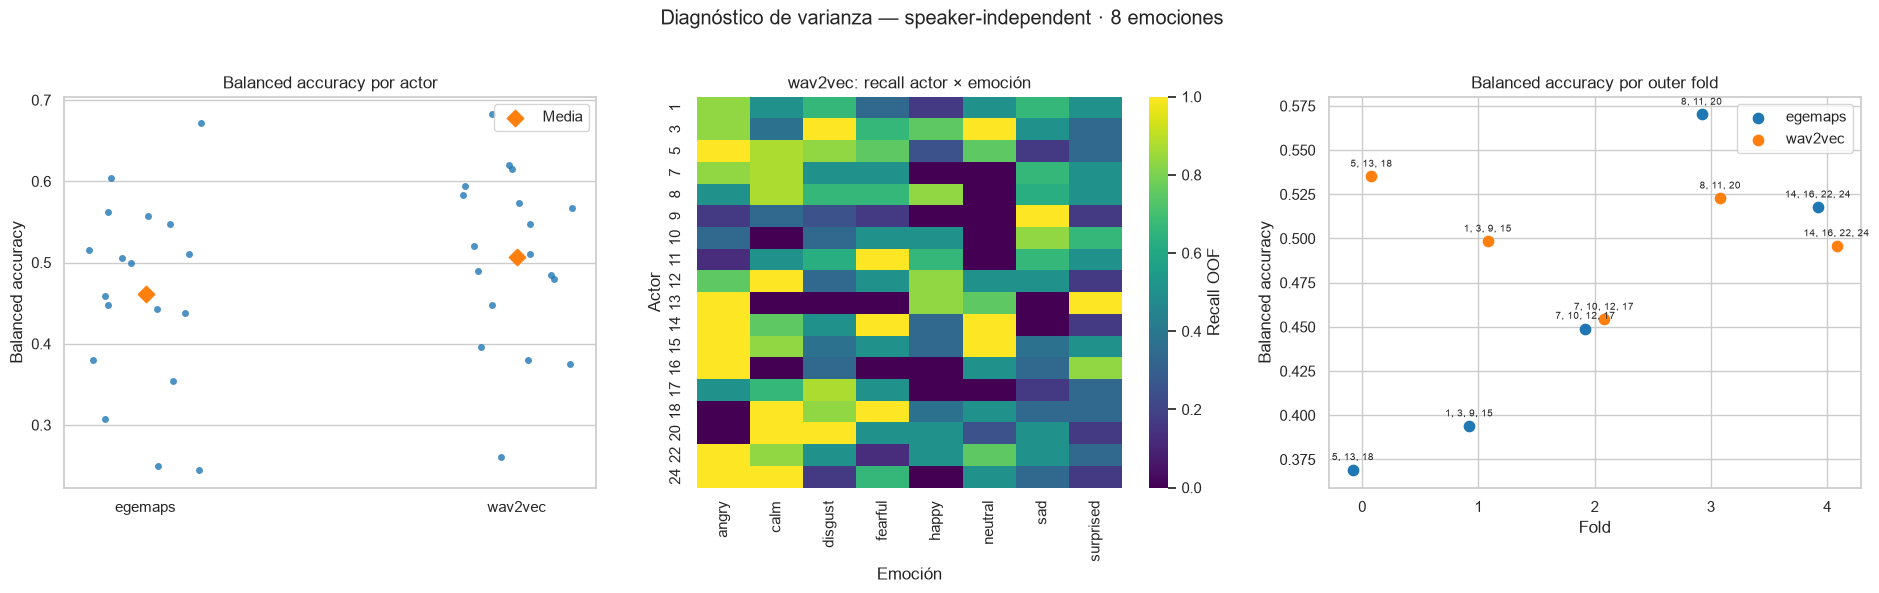

,representation,balanced_accuracy_actor_mean,balanced_accuracy_actor_std,worst_actor,best_actor,actor_range
0,egemaps,0.461,0.118,0.245,0.672,0.427
1,wav2vec,0.507,0.106,0.260,0.682,0.422


In [2]:
representations_for_lda = (
    ("egemaps", "wav2vec")
    if RUN_LDA_WAV2VEC
    else ("egemaps",)
)

oof_configs = pd.DataFrame(
    [
        {
            "representation": representation,
            "protocol": PROTOCOL,
            "target": PRIMARY_TARGET,
            "model": "logistic_regression",
            "refinement": refinement,
        }
        for representation in ("egemaps", "wav2vec")
        for refinement in (
            ("none", "lda_shrinkage")
            if representation in representations_for_lda
            else ("none",)
        )
    ]
)

collect_oof = partial(
    collect_oof_predictions,
    representations=representations,
    metadata=metadata,
    splits=splits,
    model_configs=cfg.models,
    seed=cfg.seed,
    n_folds=cfg.splits.cv_folds,
    lda_config=cfg.post_sprint3.lda,
)

if RUN_OOF_DIAGNOSTICS:
    oof_predictions = load_or_collect_oof(
        selected_configs=oof_configs,
        cache_path=OOF_PATH,
        collect_fn=collect_oof,
    )
else:
    oof_predictions = read_csv_or_empty(OOF_PATH)

baseline_oof = oof_predictions.loc[
    oof_predictions["protocol"].eq(PROTOCOL)
    & oof_predictions["target"].eq(PRIMARY_TARGET)
    & oof_predictions["model"].eq("logistic_regression")
    & oof_predictions["refinement"].eq("none")
].copy()

diagnostics = pd.concat(
    [
        build_oof_diagnostics(group, metadata).assign(
            representation=representation
        )
        for representation, group in baseline_oof.groupby(
            "representation",
            observed=True,
        )
    ],
    ignore_index=True,
)

actor_metrics = compute_actor_metrics(diagnostics)
actor_class_recall = compute_actor_class_recall(diagnostics)
fold_metrics = compute_fold_metrics_from_predictions(diagnostics)
actor_summary = summarize_actor_metrics(actor_metrics)

actor_metrics.to_csv(
    REPORTS_DIR / "actor_diagnostics.csv",
    index=False,
)

plot_actor_diagnostics(
    actor_metrics,
    actor_class_recall,
    fold_metrics,
    emotion_order=EMOTION_ORDER,
    primary_representation="wav2vec",
    title=(
        "Diagnóstico de varianza — "
        f"{PROTOCOL.replace('_', '-')} · "
        f"{TARGET_LABELS[PRIMARY_TARGET]}"
    ),
)
plt.show()

display(actor_summary.round(3))

### Lectura del diagnóstico por actor

El diagnóstico muestra que el promedio global no describe por completo el comportamiento del sistema. La dispersión entre actores es amplia en ambas representaciones y confirma que algunos hablantes resultan sistemáticamente más fáciles o más difíciles que otros.

wav2vec alcanza un rendimiento medio superior, pero esa mejora no implica necesariamente mayor estabilidad entre hablantes. La representación SSL puede explotar patrones muy informativos en ciertos actores y, al mismo tiempo, fallar con más intensidad en otros. Esto es coherente con la hipótesis de que sus embeddings conservan simultáneamente emoción, identidad vocal, prosodia individual y contenido fonético.

El mapa actor × emoción añade una segunda lectura: un actor no es simplemente “fácil” o “difícil”. En varios casos, el rendimiento cambia de manera marcada según la emoción. Por lo tanto, la fuente de variabilidad relevante no es solo el actor ni solo la clase, sino también su interacción.

El gráfico por *outer fold* debe leerse como una comparación entre particiones, no como una evolución temporal. Cada punto resume un conjunto distinto de actores de validación. Las diferencias entre folds refuerzan la necesidad de reportar dispersión además de la media.

**Limitación:** cada actor aparece en un único *outer fold*. Por eso, la métrica por actor combina la dificultad propia del hablante con pequeñas diferencias entre los modelos entrenados en cada fold. Es un diagnóstico descriptivo útil, no una estimación causal pura del “efecto actor”.


## 3. Familias acústicas eGeMAPS

Las 88 features se agrupan en siete familias. La comparación usa importancia media por feature para no favorecer automáticamente a familias más numerosas. Los tres métodos se interpretan como medidas relativas distintas; la evidencia principal proviene de coeficientes estandarizados y *permutation importance*.

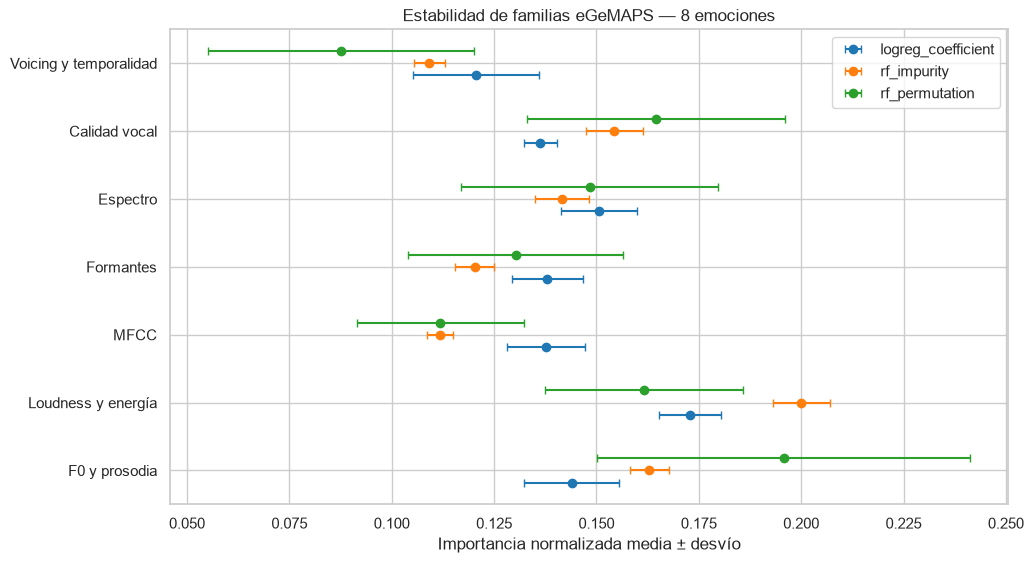

In [3]:
if feature_selection.empty:
    print(
        "Falta reports/feature_selection.csv. "
        "Ejecute primero el notebook de baselines."
    )
    family_importance = pd.DataFrame()
else:
    importance_source = feature_selection.loc[
        feature_selection["protocol"].eq(PROTOCOL)
        & feature_selection["target"].isin(FAMILY_TARGETS)
        & feature_selection["method"].isin(
            ("logreg_coefficient", "rf_impurity", "rf_permutation")
        )
    ].copy()

    feature_names = [
        column
        for column in representations["egemaps"].columns
        if column != "file_id"
    ]
    family_importance = aggregate_family_importance(
        importance_source,
        feature_names=feature_names,
    )
    family_importance = normalize_family_importance(
        family_importance
    )
    family_importance.to_csv(
        FAMILY_IMPORTANCE_PATH,
        index=False,
    )

    plot_family_importance_stability(
        family_importance,
        target=PRIMARY_TARGET,
        family_order=list(FAMILY_LABELS.values()),
        method_order=(
            "logreg_coefficient",
            "rf_impurity",
            "rf_permutation",
        ),
        title=(
            "Estabilidad de familias eGeMAPS — "
            f"{TARGET_LABELS[PRIMARY_TARGET]}"
        ),
    )
    plt.show()

### Lectura de las familias acústicas

La coincidencia entre métodos es más informativa que el ranking de un único estimador. Cuando una familia aparece de manera consistente mediante coeficientes de la regresión logística y *permutation importance*, existe evidencia más sólida de que aporta señal útil para la clasificación.

Las familias relacionadas con **energía/loudness** y **F0/prosodia** ocupan posiciones relevantes, lo cual es acústicamente razonable: intensidad, contorno tonal y dinámica prosódica son dimensiones centrales de la expresión emocional. Calidad vocal, espectro y formantes también aportan información, aunque su importancia relativa puede variar entre folds y métodos.

La importancia por impureza del Random Forest se conserva como contraste, pero no debe interpretarse como evidencia principal: puede favorecer variables continuas, correlacionadas o con mayor cantidad de puntos de corte. La *permutation importance* sobre validación y los coeficientes estandarizados son referencias más confiables para esta lectura.

Estas importancias describen asociación predictiva, no causalidad acústica. Una familia puede aparecer con importancia moderada porque su señal está distribuida o es redundante con otras familias.


## 4. Ablaciones por familia

Se separan dos preguntas que no son equivalentes:

- **Family-only:** cuánta información contiene cada familia por sí sola.
- **Leave-one-family-out:** cuánto cambia el modelo completo al remover esa familia.

El segundo panel mide aporte complementario; valores negativos indican pérdida al eliminar la familia.

2026-07-04 16:26:11 | INFO     | src.experiments.cross_validation | === CV: egemaps_logistic_regression_emotion_original_speaker_independent_all_features ===
2026-07-04 16:26:12 | INFO     | src.evaluation.metrics | [Fold 0] macro_F1=0.5835 | BalAcc=0.5938 | UAR=0.5938 | Acc=0.5875
2026-07-04 16:26:12 | INFO     | src.evaluation.metrics | [Fold 1] macro_F1=0.4543 | BalAcc=0.4297 | UAR=0.4297 | Acc=0.4417
2026-07-04 16:26:12 | INFO     | src.evaluation.metrics | [Fold 2] macro_F1=0.4645 | BalAcc=0.4883 | UAR=0.4883 | Acc=0.4750
2026-07-04 16:26:12 | INFO     | src.evaluation.metrics | [Fold 3] macro_F1=0.5217 | BalAcc=0.5234 | UAR=0.5234 | Acc=0.5333
2026-07-04 16:26:12 | INFO     | src.evaluation.metrics | [Fold 4] macro_F1=0.4266 | BalAcc=0.4297 | UAR=0.4297 | Acc=0.4500
2026-07-04 16:26:12 | INFO     | src.experiments.cross_validation | === egemaps_logistic_regression_emotion_original_speaker_independent_all_features — balanced_accuracy 0.4930 ± 0.0618 ===
2026-07-04 16:26:12 | INFO 

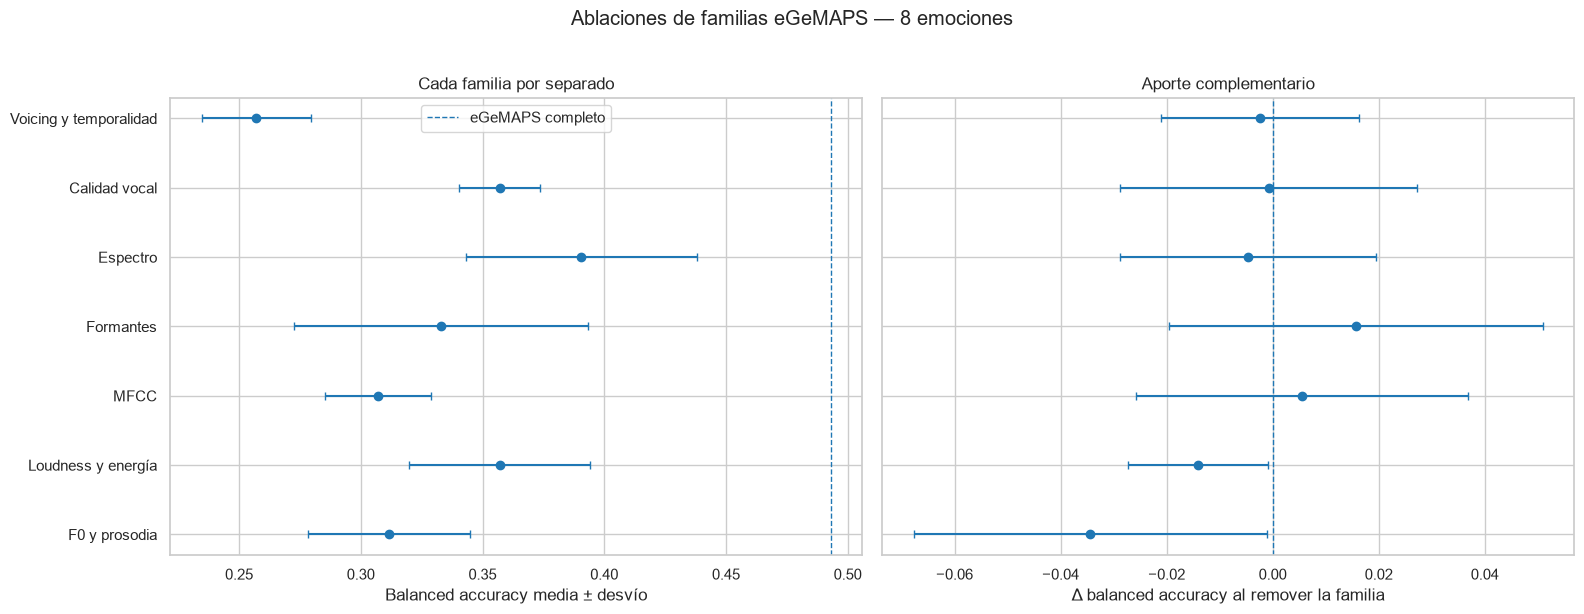

,experiment,family_label,balanced_accuracy_mean,balanced_accuracy_std,delta_mean,delta_std
0,all_features,Todas las familias,0.493,0.069,0.000,0.000
6,family_only,Voicing y temporalidad,0.257,0.022,-0.236,0.062
1,family_only,MFCC,0.307,0.022,-0.186,0.059
4,family_only,F0 y prosodia,0.312,0.033,-0.181,0.043
3,family_only,Formantes,0.333,0.060,-0.160,0.041
2,family_only,Loudness y energía,0.357,0.037,-0.136,0.060
7,family_only,Calidad vocal,0.357,0.017,-0.136,0.074
5,family_only,Espectro,0.391,0.047,-0.102,0.028
11,leave_one_family_out,F0 y prosodia,0.459,0.069,-0.034,0.033
9,leave_one_family_out,Loudness y energía,0.479,0.062,-0.014,0.013


In [4]:
if RUN_FAMILY_ABLATIONS:
    family_output = run_family_ablations(
        egemaps=representations["egemaps"],
        metadata=metadata,
        splits=splits,
        logistic_regression_config=cfg.models.logistic_regression,
        seed=cfg.seed,
        protocols=(PROTOCOL,),
        targets=FAMILY_TARGETS,
        n_folds=cfg.splits.cv_folds,
    )
    family_results = family_output["fold_results"]
    family_results.to_csv(FAMILY_RESULTS_PATH, index=False)

if family_results.empty:
    print("No hay resultados de ablaciones disponibles.")
    ablation_summary = pd.DataFrame()
else:
    ablation_summary = summarize_family_ablations(
        family_results
    )

    plot_family_ablations(
        ablation_summary,
        target=PRIMARY_TARGET,
        family_order=list(FAMILY_LABELS.values()),
        target_label=TARGET_LABELS[PRIMARY_TARGET],
    )
    plt.show()

    display(
        ablation_summary.loc[
            ablation_summary["target"].eq(PRIMARY_TARGET),
            [
                "experiment",
                "family_label",
                "balanced_accuracy_mean",
                "balanced_accuracy_std",
                "delta_mean",
                "delta_std",
            ],
        ]
        .sort_values(["experiment", "delta_mean"])
        .round(3)
    )

### Lectura de las ablaciones: información aislada y complementaria

Los experimentos `family_only` y `leave_one_family_out` responden preguntas distintas y no deben leerse como rankings equivalentes.

- **Family-only** mide cuánta estructura emocional puede recuperar una familia por sí sola.
- **Leave-one-family-out** mide cuánto pierde el sistema completo al retirar esa familia.

El patrón más interesante es que una familia puede rendir modestamente de forma aislada y, sin embargo, ser costosa de remover. Ese comportamiento indica **complementariedad**: la familia no reemplaza al resto, pero aporta información que las demás no reconstruyen por completo.

En los resultados actuales, F0/prosodia sigue este patrón con claridad. Por el contrario, algunas familias espectrales o energéticas pueden ser fuertes por sí solas y menos críticas al ser retiradas, señal de que parte de su información está redundada en otras descripciones acústicas.

Para decidir qué conocimiento experto podría guiar una futura atención temporal, el experimento `leave_one_family_out` es más relevante que `family_only`: interesa identificar qué señal deja un vacío cuando desaparece, no solamente qué familia construye el mejor clasificador aislado.


## 5. Proyección supervisada y comparación con PCA

La proyección evaluada es:

```text
StandardScaler → LDA regularizada → Logistic Regression
```

Cada transformación se ajusta dentro del *outer train*. La síntesis compara rendimiento, estabilidad y dimensionalidad efectiva sin duplicar gráficos por fold.

2026-07-04 16:26:21 | INFO     | src.experiments.cross_validation | === CV: egemaps_logistic_regression_emotion_original_speaker_independent_lda_shrinkage ===
2026-07-04 16:26:21 | INFO     | src.evaluation.metrics | [Fold 0] macro_F1=0.5621 | BalAcc=0.5625 | UAR=0.5625 | Acc=0.5667
2026-07-04 16:26:21 | INFO     | src.evaluation.metrics | [Fold 1] macro_F1=0.4437 | BalAcc=0.4219 | UAR=0.4219 | Acc=0.4375
2026-07-04 16:26:21 | INFO     | src.evaluation.metrics | [Fold 2] macro_F1=0.5106 | BalAcc=0.5352 | UAR=0.5352 | Acc=0.5250
2026-07-04 16:26:21 | INFO     | src.evaluation.metrics | [Fold 3] macro_F1=0.4621 | BalAcc=0.4648 | UAR=0.4648 | Acc=0.4833
2026-07-04 16:26:21 | INFO     | src.evaluation.metrics | [Fold 4] macro_F1=0.4982 | BalAcc=0.5039 | UAR=0.5039 | Acc=0.5083
2026-07-04 16:26:21 | INFO     | src.experiments.cross_validation | === egemaps_logistic_regression_emotion_original_speaker_independent_lda_shrinkage — balanced_accuracy 0.4977 ± 0.0499 ===
2026-07-04 16:26:21 | INF

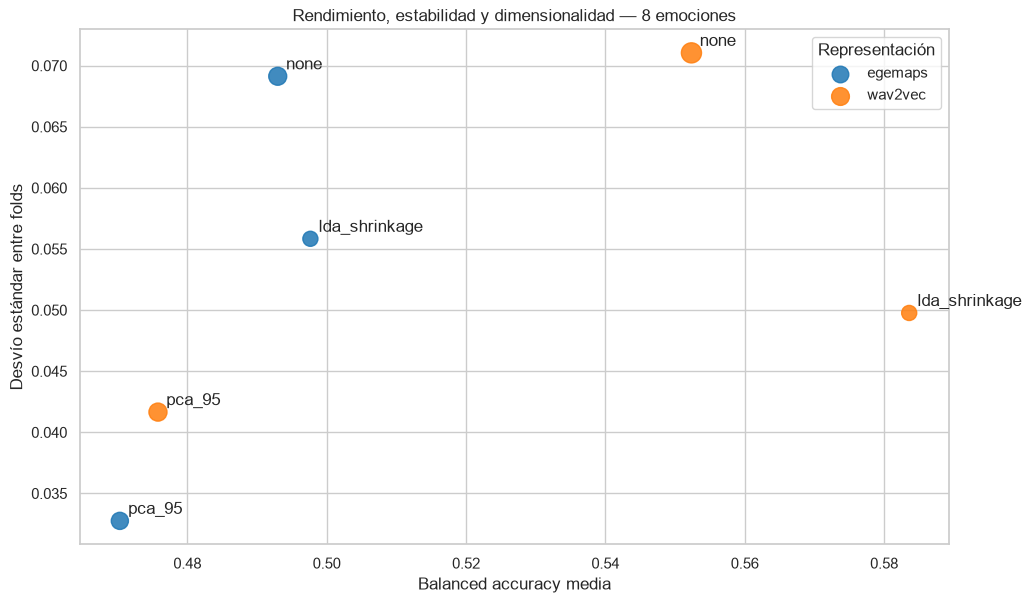

,representation,target,refinement,balanced_accuracy_mean,balanced_accuracy_std,n_features_mean,n_folds
3,wav2vec,emotion_original,lda_shrinkage,0.584,0.050,7.0,5
4,wav2vec,emotion_original,none,0.552,0.071,768.0,5
0,egemaps,emotion_original,lda_shrinkage,0.498,0.056,7.0,5
1,egemaps,emotion_original,none,0.493,0.069,88.0,5
5,wav2vec,emotion_original,pca_95,0.476,0.042,96.6,5
2,egemaps,emotion_original,pca_95,0.470,0.033,40.2,5


In [5]:
if RUN_LDA:
    lda_output = run_lda_grid(
        representations=representations,
        metadata=metadata,
        splits=splits,
        logistic_regression_config=cfg.models.logistic_regression,
        seed=cfg.seed,
        representation_names=representations_for_lda,
        protocols=(PROTOCOL,),
        targets=LDA_TARGETS,
        shrinkage=cfg.post_sprint3.lda.shrinkage,
        n_folds=cfg.splits.cv_folds,
    )
    cv_results = upsert_cv_results(
        cv_results,
        lda_output["fold_results"],
    )
    save_cv_results(cv_results, CV_RESULTS_PATH)

projection_summary = summarize_projection_results(
    cv_results,
    protocol=PROTOCOL,
    target=PRIMARY_TARGET,
    refinements=("none", "pca_95", "lda_shrinkage"),
)

if projection_summary.empty:
    print("No hay resultados baseline/PCA/LDA para comparar.")
else:
    plot_projection_tradeoff(
        projection_summary,
        title=(
            "Rendimiento, estabilidad y dimensionalidad — "
            f"{TARGET_LABELS[PRIMARY_TARGET]}"
        ),
    )
    plt.show()

    display(
        projection_summary.sort_values(
            ["balanced_accuracy_mean", "balanced_accuracy_std"],
            ascending=[False, True],
        ).round(3)
    )

### Lectura de PCA frente a LDA

PCA y LDA comprimen la representación con objetivos diferentes:

- **PCA** conserva varianza global sin utilizar las etiquetas.
- **LDA** busca direcciones discriminantes ajustadas con las clases dentro del *outer train*.

La proyección LDA reduce cada representación a `n_clases - 1` dimensiones. Para ocho emociones, esto implica una compresión muy fuerte, especialmente en wav2vec. Que esa reducción mantenga o mejore la balanced accuracy indica que buena parte de la variabilidad original no es necesaria para la frontera emocional lineal.

El resultado más relevante no es solo la media. En wav2vec, LDA combina mejor rendimiento con menor dispersión entre folds; en eGeMAPS, la ganancia media es más limitada, pero la reducción de variabilidad sigue siendo informativa. PCA, en cambio, comprime sin preservar necesariamente las direcciones útiles para la emoción y puede eliminar señal discriminante de baja varianza.

LDA no demuestra que la representación haya quedado libre de identidad vocal. Solo muestra que una proyección supervisada global puede concentrar mejor la señal de clase para una sonda lineal. La variabilidad por actor observada antes sigue justificando investigar representaciones temporales y mecanismos de atención.


## 6. Matrices OOF: baseline frente a LDA

Las matrices se normalizan por clase verdadera. El tercer panel muestra `LDA − baseline`, por lo que la diagonal permite localizar ganancias o pérdidas de recall específicas por emoción.

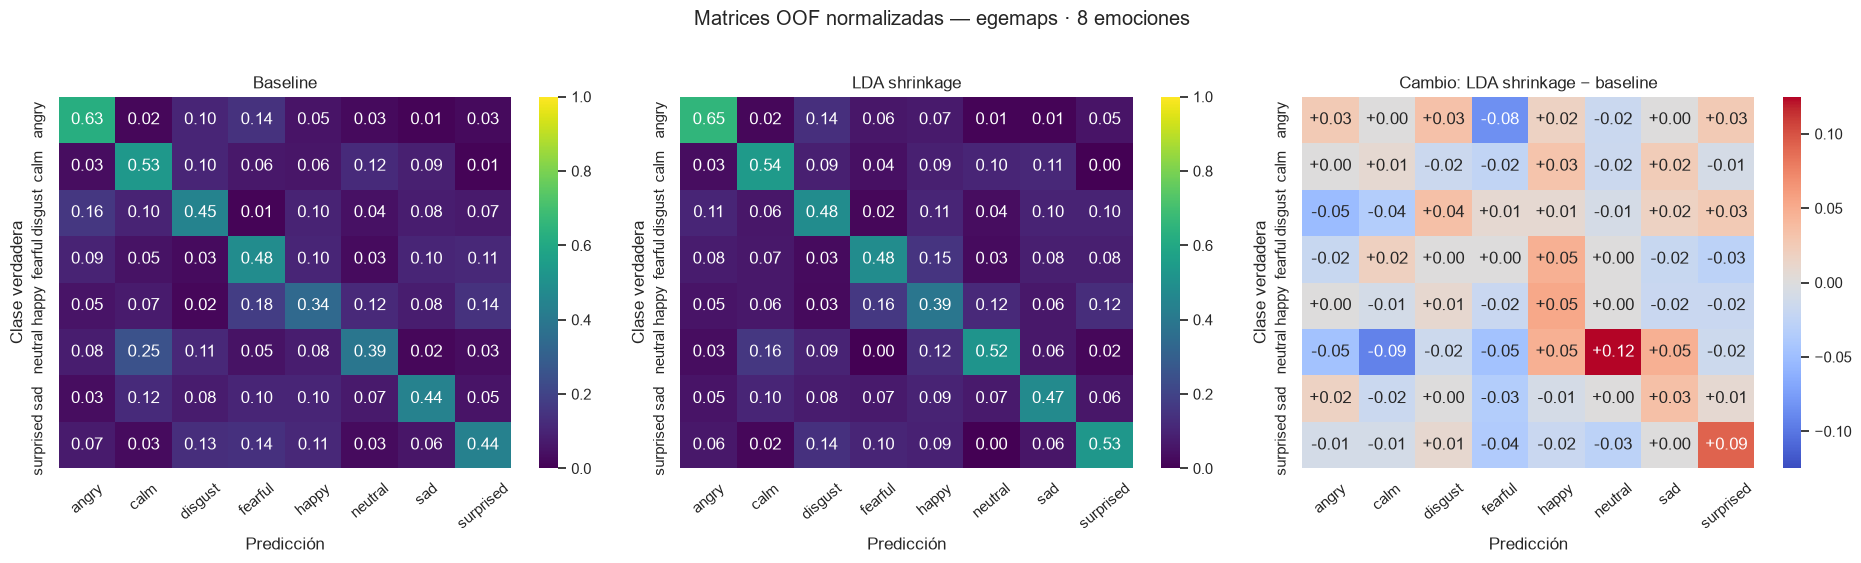

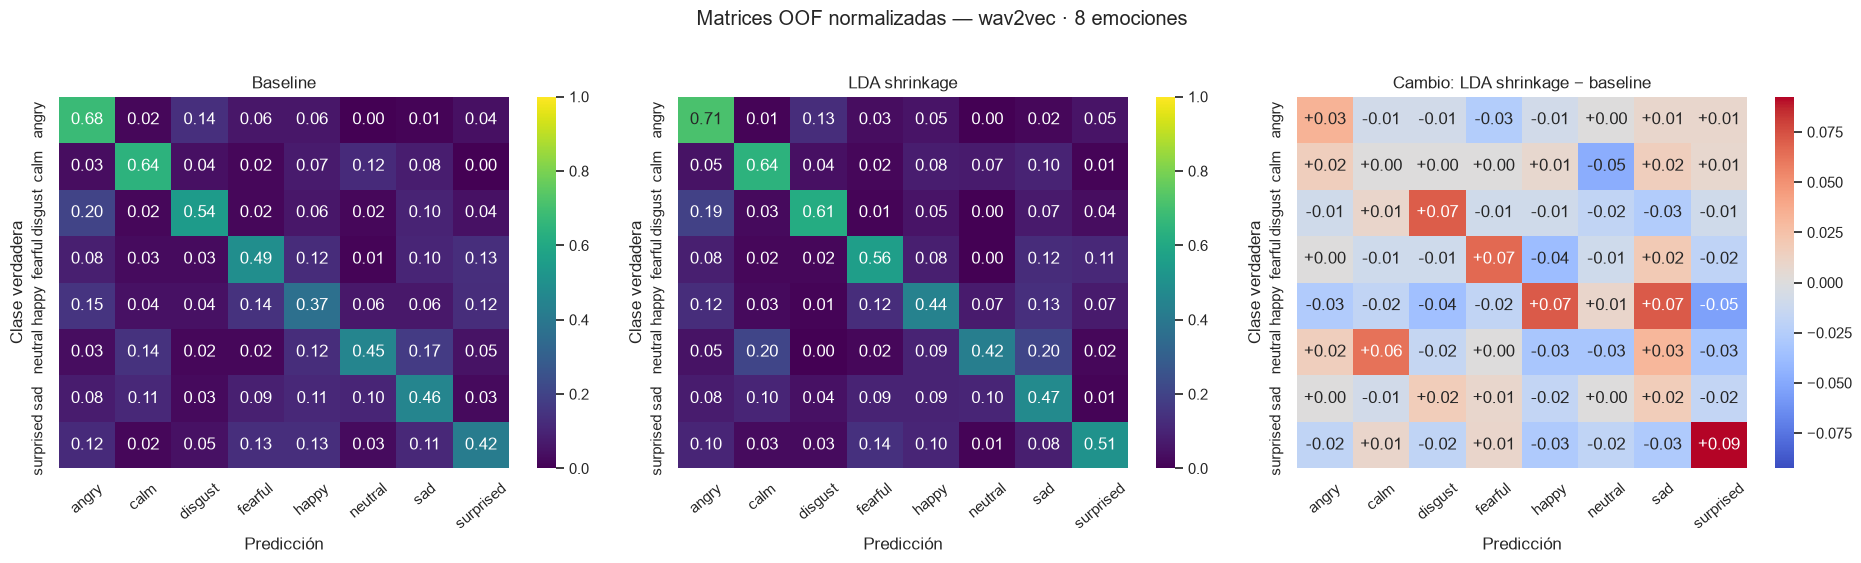

In [6]:
for representation in representations_for_lda:
    baseline_config = {
        "representation": representation,
        "protocol": PROTOCOL,
        "target": PRIMARY_TARGET,
        "model": "logistic_regression",
        "refinement": "none",
    }
    lda_config = {
        **baseline_config,
        "refinement": "lda_shrinkage",
    }

    baseline_predictions = oof_predictions.loc[
        configuration_mask(
            oof_predictions,
            baseline_config,
        )
    ]
    lda_predictions = oof_predictions.loc[
        configuration_mask(
            oof_predictions,
            lda_config,
        )
    ]

    if baseline_predictions.empty or lda_predictions.empty:
        print(
            "Predicciones OOF incompletas para:",
            representation,
        )
        continue

    plot_confusion_comparison(
        baseline_predictions,
        lda_predictions,
        labels=EMOTION_ORDER,
        representation_name=(
            f"{representation} · {TARGET_LABELS[PRIMARY_TARGET]}"
        ),
        refinement_label="LDA shrinkage",
    )
    plt.show()

### Lectura de las matrices baseline frente a LDA

Las matrices OOF permiten comprobar si una mejora agregada está distribuida entre las clases o concentrada en unas pocas emociones.

La tercera matriz es la más informativa: valores positivos en la diagonal indican una ganancia de recall para esa emoción; valores negativos indican una pérdida. Los cambios fuera de la diagonal muestran qué confusiones específicas se redistribuyen con la proyección.

En eGeMAPS, LDA produce cambios relativamente acotados y redistribuye errores entre emociones cercanas, en línea con una mejora global pequeña. En wav2vec, la modificación es más marcada: algunas emociones ganan separación, aunque otras confusiones permanecen o se desplazan hacia nuevas clases.

Por eso, una mejora de balanced accuracy no debe describirse como una mejora uniforme. LDA cambia la geometría discriminante y favorece algunas fronteras más que otras. Para el informe final conviene acompañar la métrica global con uno o dos ejemplos concretos de clases beneficiadas y perjudicadas.


### Conclusión del notebook

Las tres preguntas iniciales quedan respondidas de manera consistente con las evidencias visuales y tabulares:

**1. Variabilidad entre actores y emociones.** El rendimiento depende fuertemente del hablante y de la interacción actor–emoción. wav2vec mejora el promedio, pero no elimina la heterogeneidad entre voces. Esto impide interpretar la ventaja SSL como una generalización uniforme.

**2. Familias acústicas útiles.** Energía, prosodia, calidad vocal y estructura espectral aportan información distribuida. Las ablaciones muestran que la utilidad aislada y el aporte complementario no son equivalentes: F0/prosodia es especialmente relevante como señal complementaria, aun cuando no sea la mejor familia usada por sí sola.

**3. Proyección supervisada.** LDA es más adecuada que PCA para concentrar la información emocional de una sonda lineal. En wav2vec ofrece el compromiso más favorable entre rendimiento, estabilidad y dimensionalidad; en eGeMAPS actúa principalmente como regularizador y compresor.

La conclusión metodológica no es que una proyección global resuelva por completo SER. Persisten diferencias fuertes entre actores y emociones, y las estadísticas globales pierden la evolución temporal de F0, energía, calidad vocal y espectro. Estos resultados justifican la siguiente extensión: representar secuencias acústicas y aprender un pooling temporal que pueda ponderar regiones informativas sin confundirlas con identidad vocal o silencio.
